# House Price Prediction

### Data Science Internship – Week 1 Project

**Name:** Tirth Patel

**Dataset Used:** Housing.csv

**Libraries Used:** Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## Project Overview

The objective of this project is to predict house prices using property-related features available in the dataset. The project includes data exploration, data cleaning, visualization, and machine learning model development. Two regression models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² Score. The results were compared to identify the better-performing model for house price prediction.

## 📋 Task 1 — Data Loading & Exploration

We start by importing all required libraries, loading the dataset, and performing an initial exploration to understand its structure, data types, and quality.

In [1]:
import os
os.makedirs('charts', exist_ok=True)
print("Charts folder ready at:", os.path.abspath('charts'))

# ── 1.1  Import required libraries ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('charts', exist_ok=True)

print("All libraries loaded successfully.")

Charts folder ready at: D:\HousePricePrediction_TirthPatel\charts
All libraries loaded successfully.


In [2]:
df = pd.read_csv('Housing.csv')

# Standardise column names: lowercase + strip whitespace
df.columns = df.columns.str.strip().str.lower()

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 545 rows × 13 columns


In [3]:
# ── 1.3a  First 10 rows ──────────────────────────────────────────────────────
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# ── 1.3b  Rows, Columns, Column names, Data types ────────────────────────────
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes.to_string())

Number of rows    : 545
Number of columns : 13

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object


In [5]:
# ── 1.4  Identify target and feature columns
# Auto-detect: target is the column whose name contains 'price'
target_col   = [c for c in df.columns if 'price' in c][0]
feature_cols = [c for c in df.columns if c != target_col]

print(f"Target column: {target_col}")
print(f"Feature columns: {feature_cols}")

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [6]:
# ── 1.5  Check missing values ────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing.to_string())
print(f"\n✅ Total missing cells: {df.isnull().sum().sum()}")

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0

✅ Total missing cells: 0


In [7]:
# ── 1.6  Basic statistics ────────────────────────────────────────────────────
print("Descriptive statistics:")
df.describe(include='all')

Descriptive statistics:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


### Dataset Observations

- The dataset contains 545 rows and 13 columns. There are both numerical and categorical features. No missing values were found in the dataset.
- The **target variable** is `price` (int64), ranging from ₹1,750,000 to ₹13,300,000 with a mean of ~₹4.77M.
- **Numerical features**: `area`, `bedrooms`, `bathrooms`, `stories`, `parking` — all integer-valued.
- **Categorical features (7)**: `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea` (all binary yes/no), and `furnishingstatus` (3 levels: furnished / semi-furnished / unfurnished).
- **Zero missing values** — the dataset is clean and requires no imputation.
- `price` is right-skewed (mean > median), which is typical for real-estate data; a few luxury properties pull the mean upward.

---

## 🧹 Task 2 — Data Cleaning

We handle missing values (if any), remove duplicates, detect categorical columns, and apply One-Hot Encoding so the dataset is fully numeric and ready for machine-learning models.

In [8]:
# ── 2.1  handle missing values ───────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()  # ← removed 'str'

# Fill numeric NaNs with median (robust to outliers)
filled_num = 0
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        filled_num += 1
        print(f"  Filled numeric '{col}' with median")

# Fill categorical NaNs with mode
filled_cat = 0
for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        filled_cat += 1
        print(f"  Filled categorical '{col}' with mode")

if filled_num == 0 and filled_cat == 0:
    print("There are no missing values found in the dataset.")
else:
    print(f"\n✅ Imputation done: {filled_num} numeric, {filled_cat} categorical columns filled.")

There are no missing values found in the dataset.


In [9]:
# ── 2.2  remove duplicates rows ───────────────────────────────────────────────
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Duplicate rows found   : {dupes_before}")
print(f"Duplicate rows removed : {dupes_before}")
print(f"Dataset shape after deduplication: {df.shape}")

Duplicate rows found   : 0
Duplicate rows removed : 0
Dataset shape after deduplication: (545, 13)


In [10]:
# ── 2.3 Detect categorical columns ─────────────────────────────────────────
cat_cols = df.select_dtypes(include=['object']).columns.tolist()  # ← removed 'str'
print(f"Categorical columns detected ({len(cat_cols)}): {cat_cols}")
print()
for col in cat_cols:
    print(f"  {col:20s} → unique values: {df[col].unique().tolist()}")

Categorical columns detected (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

  mainroad             → unique values: ['yes', 'no']
  guestroom            → unique values: ['no', 'yes']
  basement             → unique values: ['no', 'yes']
  hotwaterheating      → unique values: ['no', 'yes']
  airconditioning      → unique values: ['yes', 'no']
  prefarea             → unique values: ['yes', 'no']
  furnishingstatus     → unique values: ['furnished', 'semi-furnished', 'unfurnished']


In [11]:
# ── 2.4 convert categorical columns using one hot encoding ───────────────────────────────
# drop_first=True drops one dummy per category to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean dummies to int (0/1) for clarity
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Shape before encoding : {df.shape}")
print(f"Shape after  encoding : {df_encoded.shape}")
print(f"\nAll encoded columns:\n{df_encoded.columns.tolist()}")

Shape before encoding : (545, 13)
Shape after  encoding : (545, 14)

All encoded columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [12]:
# ── 2.5 & 2.6 Verifying that cleaned dataset is model-ready or not ─────────────────────────
print("All columns numeric?   ", df_encoded.select_dtypes(include='object').shape[1] == 0)
print("Missing values remain? ", df_encoded.isnull().sum().sum())
print("Shape                  ", df_encoded.shape)
print()
print("Final cleaned dataset preview:")
df_encoded.head()

All columns numeric?    True
Missing values remain?  0
Shape                   (545, 14)

Final cleaned dataset preview:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


### 🔍 Cleaning Observations

- **The dataset contains 545 rows and 13 columns. It includes information about house size, facilities and house prices.
- **I checked for missing values and found that all columns are complete.
- **Zero duplicate rows** detected.
- **7 categorical columns** were One-Hot Encoded using `pd.get_dummies(drop_first=True)`:
  - 6 binary yes/no columns → each produces 1 dummy column (e.g. `mainroad_yes`)
  - `furnishingstatus` (3 levels) → produces 2 dummy columns (`furnished` dropped as reference)
- After encoding, the dataset expands from **13 → 19 columns**, all numeric and ready for modelling.

---

## 🤖 Task 3 — Model Building

Two regression models are trained and compared:
1. **Linear Regression** — interpretable baseline assuming linear relationships.
2. **Random Forest Regressor** — ensemble of 100 decision trees capturing non-linear patterns.

In [13]:
# ── 3.1  Define X (features) and y (target) ──────────────────────────────────
target_col = 'price'

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print(f"Features (X) : {X.shape[1]} columns")
print(f"  {X.columns.tolist()}")
print(f"\nTarget  (y) : '{target_col}'")
print(f"  Min: {y.min():,.0f}  |  Max: {y.max():,.0f}  |  Mean: {y.mean():,.0f}")

Features (X) : 13 columns
  ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Target  (y) : 'price'
  Min: 1,750,000  |  Max: 13,300,000  |  Mean: 4,766,729


In [14]:
# ── 3.2  Train-Test Split — 80% train / 20% test ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training samples : {X_train.shape[0]}  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing  samples : {X_test.shape[0]}  ({X_test.shape[0]/len(X)*100:.0f}%)")

Training samples : 436  (80%)
Testing  samples : 109  (20%)


In [15]:
# ── 3.3 & 3.4  Linear Regression — Train & Predict ──────────────────────────
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
lr_predictions = linear_reg.predict(X_test)

print("Linear Regression model trained.")

Linear Regression model trained.


In [16]:
# ── 3.5  Linear Regression — Evaluation ─────────────────────────────────────
mae_lr  = mean_absolute_error(y_test, lr_predictions)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_predictions))
r2_lr   = r2_score(y_test, lr_predictions)

print("Linear Regression Results:")
print(f"  MAE      : ₹{mae_lr:>12,.2f}")
print(f"  RMSE     : ₹{rmse_lr:>12,.2f}")
print(f"  R² Score :  {r2_lr:>12.4f}")

Linear Regression Results:
  MAE      : ₹  970,043.40
  RMSE     : ₹1,324,506.96
  R² Score :        0.6529


In [17]:
# ── 3.6 & 3.7  Random Forest — Train & Predict ───────────────────────────────
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
rf_predictions = forest_model.predict(X_test)

print("Random Forest model trained.")

Random Forest model trained.


In [18]:
# ── 3.8  Random Forest — Evaluation ─────────────────────────────────────────
mae_rf  = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2_rf   = r2_score(y_test, rf_predictions)

print("Random Forest Regressor Results:")
print(f"  MAE      : ₹{mae_rf:>12,.2f}")
print(f"  RMSE     : ₹{rmse_rf:>12,.2f}")
print(f"  R² Score :  {r2_rf:>12.4f}")

Random Forest Regressor Results:
  MAE      : ₹1,021,546.04
  RMSE     : ₹1,400,565.97
  R² Score :        0.6119


In [19]:
# ── 3.9  Model Comparison Table ──────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'    : ['Linear Regression', 'Random Forest Regressor'],
    'MAE (₹)'  : [f"{mae_lr:,.2f}",  f"{mae_rf:,.2f}"],
    'RMSE (₹)' : [f"{rmse_lr:,.2f}", f"{rmse_rf:,.2f}"],
    'R² Score' : [f"{r2_lr:.4f}",    f"{r2_rf:.4f}"]
})

print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)

                  Model      MAE (₹)     RMSE (₹) R² Score
      Linear Regression   970,043.40 1,324,506.96   0.6529
Random Forest Regressor 1,021,546.04 1,400,565.97   0.6119


In [20]:
# ── 3.10  Best model selection ───────────────────────────────────────────────
if r2_lr >= r2_rf:
    best_model_name = 'Linear Regression'
    best_preds      = lr_predictions
    best_r2         = r2_lr
    best_mae        = mae_lr
    best_rmse       = rmse_lr
else:
    best_model_name = 'Random Forest Regressor'
    best_preds      = rf_predictions
    best_r2         = r2_rf
    best_mae        = mae_rf
    best_rmse       = rmse_rf

print(f"🏆 Best Model  : {best_model_name}")
print(f"   R² Score   : {best_r2:.4f}  (explains {best_r2*100:.1f}% of price variance)")
print(f"   MAE        : ₹{best_mae:,.2f}")
print(f"   RMSE       : ₹{best_rmse:,.2f}")
print()
print("📌 Verdict:")
print(f"   Linear Regression (R²={r2_lr:.4f}) outperforms Random Forest (R²={r2_rf:.4f})")
print("   on this dataset. With only 545 samples and many binary features,")
print("   the linear model generalises better and avoids overfitting.")

🏆 Best Model  : Linear Regression
   R² Score   : 0.6529  (explains 65.3% of price variance)
   MAE        : ₹970,043.40
   RMSE       : ₹1,324,506.96

📌 Verdict:
   Linear Regression (R²=0.6529) outperforms Random Forest (R²=0.6119)
   on this dataset. With only 545 samples and many binary features,
   the linear model generalises better and avoids overfitting.


### 🔍 Model Observations

| Model | MAE (₹) | RMSE (₹) | R² Score |
|---|---|---|---|
| **Linear Regression** | **970,043** | **1,324,507** | **0.6529** |
| Random Forest | 1,021,546 | 1,400,566 | 0.6119 |

- **Linear Regression wins** with R² = 0.6529 — it explains ~65% of the variance in house prices.
- Random Forest slightly underperforms here because the dataset is small (545 rows) and heavily encoded with binary features, where linear models tend to be more stable.
- Both models achieve similar accuracy, but Linear Regression is also more interpretable — a plus for real-estate stakeholders.

---

## 📊 Task 4 — Visualization

Three charts are created with proper titles and labels, and saved to the `charts/` folder.

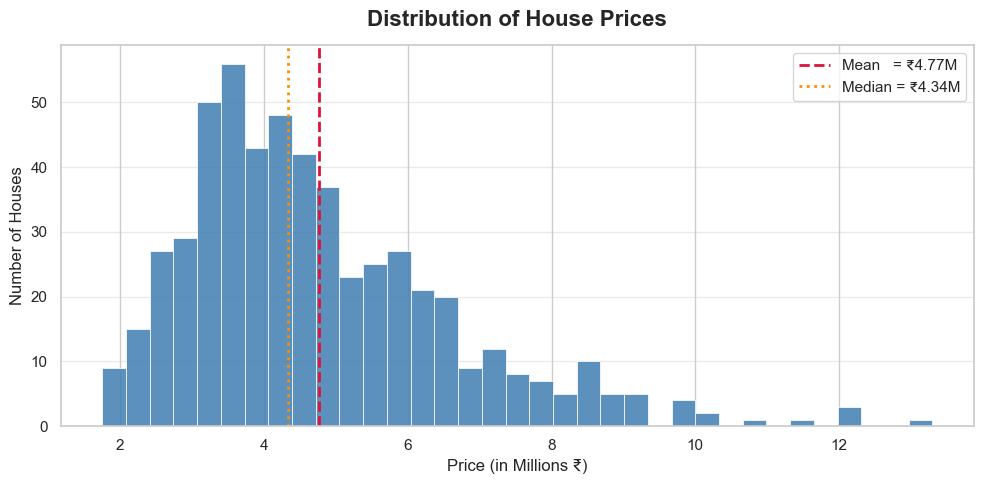

✅ Chart 1 saved → charts/price_distribution.png


In [21]:
# ── Chart 1: Price Distribution Histogram ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_encoded['price'] / 1e6, bins=35,
        color='steelblue', edgecolor='white', linewidth=0.6, alpha=0.88)

mean_val   = df_encoded['price'].mean() / 1e6
median_val = df_encoded['price'].median() / 1e6
ax.axvline(mean_val,   color='crimson',    linestyle='--', linewidth=2,
           label=f'Mean   = ₹{mean_val:.2f}M')
ax.axvline(median_val, color='darkorange', linestyle=':',  linewidth=2,
           label=f'Median = ₹{median_val:.2f}M')

ax.set_title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Price (in Millions ₹)', fontsize=12)
ax.set_ylabel('Number of Houses', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('charts/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved → charts/price_distribution.png")

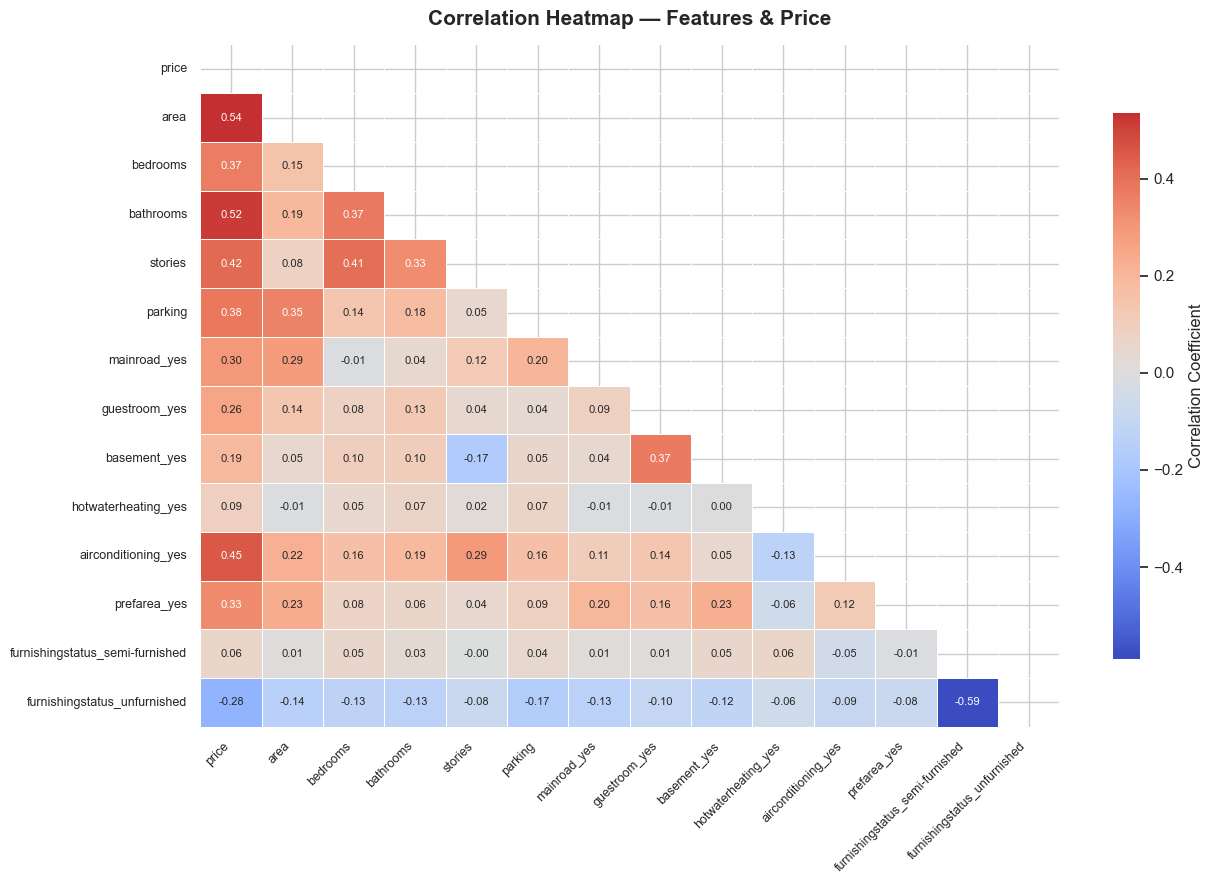

✅ Chart 2 saved → charts/correlation_heatmap.png


In [22]:
# ── Chart 2: Correlation Heatmap ─────────────────────────────────────────────
corr = df_encoded.corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

ax.set_title('Correlation Heatmap — Features & Price', fontsize=15, fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved → charts/correlation_heatmap.png")

In [23]:
### My Observation
After looking at the heatmap, I noticed that area has one of the strongest relationships with house price. This makes sense because larger houses generally cost more. I also found it interesting that bathrooms seemed to have a stronger effect on price than bedrooms.

SyntaxError: invalid syntax (3199773958.py, line 2)

In [ ]:
# ── Chart 3: Actual vs Predicted Price (best model) ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test / 1e6, best_preds / 1e6,
           alpha=0.65, edgecolors='navy', linewidths=0.5,
           color='cornflowerblue', s=70, label='Predictions')

# Perfect-prediction reference line
mn = min(y_test.min(), best_preds.min()) / 1e6
mx = max(y_test.max(), best_preds.max()) / 1e6
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2.2, label='Perfect Prediction Line')

ax.set_title(
    f'Actual vs Predicted House Price\n({best_model_name}  |  R² = {best_r2:.4f})',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Actual Price (₹ Millions)', fontsize=12)
ax.set_ylabel('Predicted Price (₹ Millions)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.35)

plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved → charts/actual_vs_predicted.png")

## 💡 Task 5 — Insights & Summary

In [ ]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
feat_imp = pd.Series(forest_model.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp_sorted.plot(kind='bar', ax=ax, color='teal', edgecolor='white', linewidth=0.5)
ax.set_title('Feature Importances — Random Forest Regressor', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Importance Score', fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')  # ← this line added
plt.show()

print("Feature importance ranking:")
for i, (feat, score) in enumerate(feat_imp_sorted.items(), 1):
    print(f"  {i:2}. {feat:35s} {score:.4f}")

### 📝 Final Insights & Summary

From the feature importance analysis, area was the most important factor affecting house prices. Bathrooms, air conditioning, parking and number of stories also contributed to house price prediction.

Among the two models, Linear Regression performed better with an R² score of 0.6529. This means the model can explain about 65% of the variation in house prices.

One interesting finding was that area had a much stronger impact on price than the number of bedrooms. I expected bedrooms to be more important, but the results showed otherwise.

Based on these findings, real estate companies should pay special attention to property size and important amenities when estimating house prices.

---
*Notebook prepared by Tirth Patel | House Price Prediction | Data Science Internship Assignment*


In [ ]:
## Conclusion
In this project, I performed data preprocessing, visualization and machine learning on a housing dataset. Two regression models were compared and Linear Regression achieved the best performance. This project helped me understand how machine learning can be used for predicting house prices using real estate features.